In [1]:
import pandas as pd
from warnings import filterwarnings
import random

import torch.cuda as cuda
from scipy.sparse import csr_matrix
from scipy.io import mmread

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# 读取稀疏矩阵文件
matrix = mmread('../data/pan_cancer/matrix.mtx')

In [3]:
compress_matrix = csr_matrix(matrix)

# 读取 barcodes 和 features 文件
barcodes = pd.read_csv('../data/pan_cancer/barcodes.tsv', header=None)
features = pd.read_csv('../data/pan_cancer/features.tsv', header=None)

adata = sc.AnnData(X=compress_matrix.transpose())
adata.var_names = features[0].values
adata.obs_names = barcodes[0].values

metadata = pd.read_csv('../data/pan_cancer/metadata.tsv', sep='\t')
adata.obs = metadata

adata.write('../cache/pan_cancer_matrix.h5ad')

In [2]:
adata = sc.read_h5ad('../cache/pan_cancer_matrix.h5ad')
adata_ESCA = adata[adata.obs['Cancer'] == 'ESCA']

In [3]:
PatientID = adata_ESCA.obs['PatientID'].unique()

In [4]:
# adata_ESCA_train = adata_ESCA[adata_ESCA.obs['PatientID'].isin(list(PatientID)[0:8])]
adata_subset = adata_ESCA[adata_ESCA.obs['PatientID'].isin(list(PatientID)[0:2])]
adata_subset

View of AnnData object with n_obs × n_vars = 2630 × 18315
    obs: 'SampleID', 'PatientID', 'Cancer', 'Tissue', 'Tumor_stage', 'Annotation'

In [5]:
batch_labels_list = adata_subset.obs['PatientID']
# batch_labels_list = None

In [6]:
RNA_matrix = adata_subset.X.transpose()

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_size = 30

initial_pre = initial_clustering(RNA_matrix)
# initial_pre = initial_clustering(adata_subset.raw.X)

cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]
# partite the data into batches
indices, Node_Ids, dic = batch_select_whole(RNA_matrix, cell_size=cell_size)
n_batch = len(indices)

output_file = '../data/pan_cancer/output/ESCA'
os.makedirs(output_file, exist_ok=True)

device = torch.device("cuda" if cuda.is_available() else "cpu")

node_model = NDR_2(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8, enable_batch_correction=True,
                   batch_source=batch_labels_list,
                   n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                   num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.
正在从磁盘加载处理后的数据...
The training process for the NodeDimensionReduction model has started. Please wait.


Epochs: 100%|██████████| 100/100 [14:27<00:00,  8.67s/it]

The training for the NodeDimensionReduction model has been completed.


In [7]:
ScFormer_result = pred(
    RNA_matrix, gnn=gnn, indices=indices, device=device
)
# Save numpy arrays to files
# output_file = "data/mouse_retina/output"
np.save(output_file + "/Node_Ids.npy", Node_Ids)
np.save(output_file + "/pred.npy", ScFormer_result["pred_label"])
np.save(output_file + "/cell_embedding.npy", ScFormer_result["cell_embedding"])

Prediction Batches: 100%|██████████| 88/88 [00:06<00:00, 14.24it/s]


In [8]:
node_ids = np.load(output_file + "/node_ids.npy")
cell_emb = np.load(output_file + "/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata_subset.obsm["cell_emb"] = cell_emb_sorted.values

In [9]:
pred = np.load(output_file + '/pred.npy')
pred_ = pd.DataFrame(pred, index=Node_Ids)
pred_sorted = pred_.sort_index()
adata_subset.obs['pre'] = pred_sorted.values
adata_subset.obs['pre'] = adata_subset.obs['pre'].astype('category')

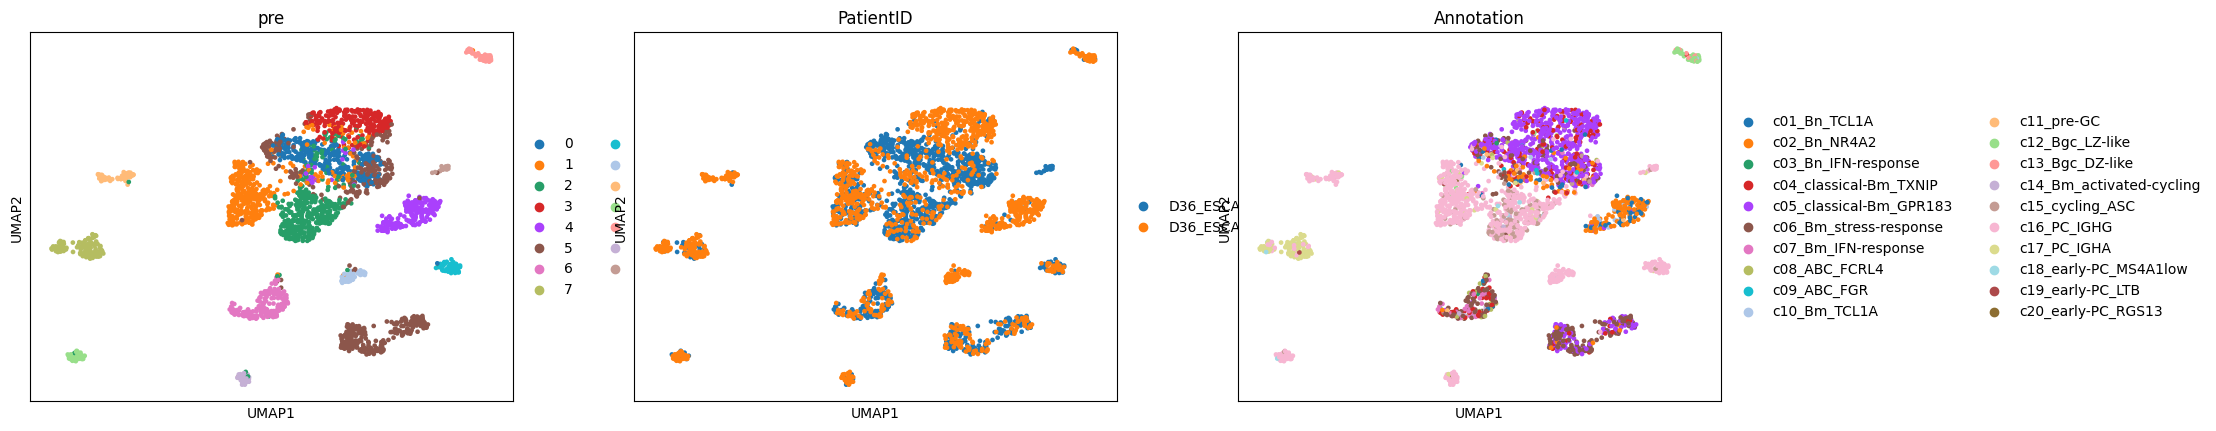

In [10]:
adata_subset.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata_subset, use_rep="cell_emb")
sc.tl.umap(adata_subset)

sc.pl.umap(adata_subset, color=['pre', 'PatientID', 'Annotation'], show=True)

         Falling back to preprocessing with `sc.pp.pca` and default params.


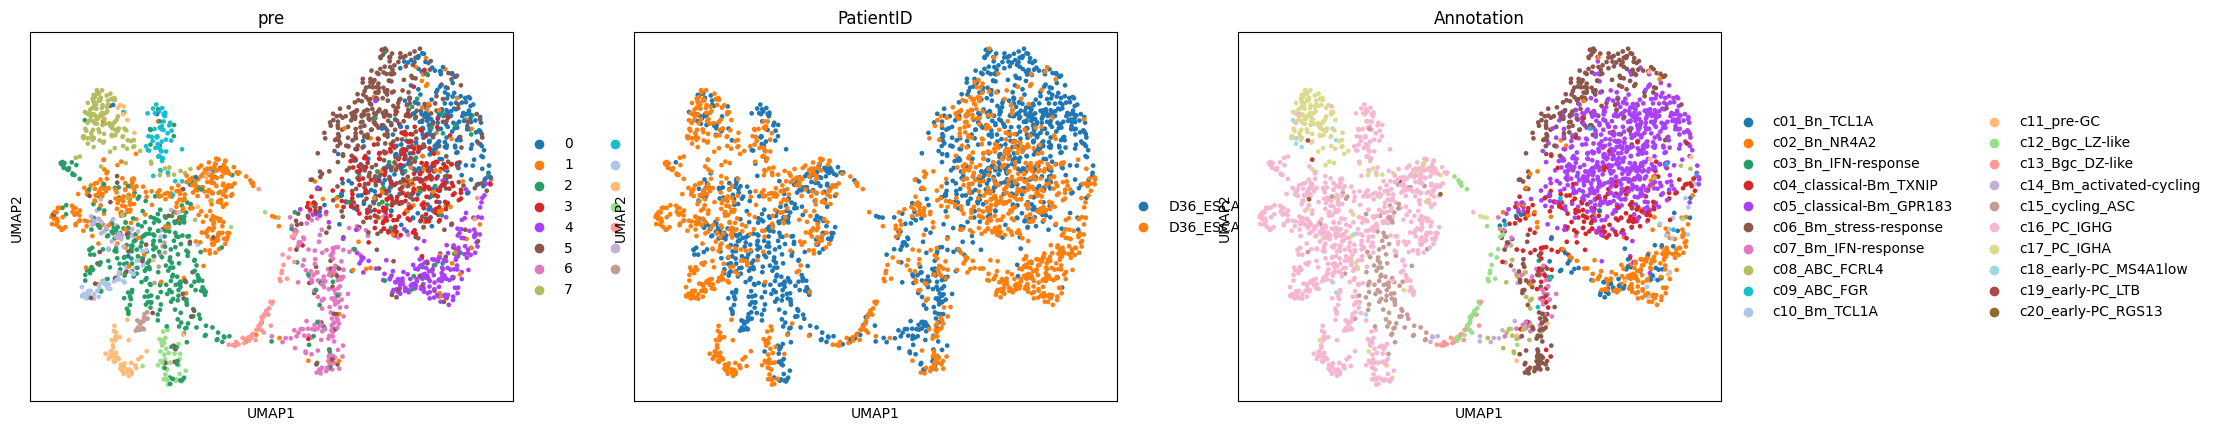

In [11]:
sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata_subset)
sc.tl.umap(adata_subset)
sc.pl.umap(adata_subset, color=['pre', 'PatientID', 'Annotation'], show=True)